# 🏆 Análisis deportivo automatizado con YOLO + SAM3

Este notebook demuestra un **pipeline híbrido** para la detección y análisis de robots, balón y campo en partidos de fútbol robótico.  
El enfoque se basa en:

- **YOLO fine-tuneado**: modelo entrenado para detectar las clases `balón`, `campo`, `robot aliado` y `robot rival`.  
- **ByteTrack**: asignación de IDs persistentes para rastrear trayectorias de cada robot y del balón.  
- **SAM3**: segmentación precisa del campo y objetos, utilizando como entrada las **cajas y coordenadas almacenadas en el CSV generado por YOLO en la Fase 1**.  
- **Visualización y análisis**: generación de trazas, mapas de calor y métricas de posesión a partir de las detecciones.

In [21]:
import supervision as sv
import cv2, numpy as np, torch
import ultralytics
import torch
import csv
from collections import defaultdict
from ultralytics import YOLO, SAM
from ultralytics.models.sam import SAM3VideoSemanticPredictor
from trackers import ByteTrackTracker
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd


print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(f"Supervision: {sv.__version__}")
print(f"Ultralytics: {ultralytics.__version__}")
print("¡Todo listo!")


2.5.1
True
NVIDIA GeForce RTX 4060
Supervision: 0.28.0
Ultralytics: 8.4.61
¡Todo listo!


In [ ]:
yolo_model = YOLO("runs/runs/detect/train-7/weights/best.pt").to("cuda")
sam_model  = SAM("sam3.pt").to("cuda")
tracker    = ByteTrackTracker()

## Prueba 1 – Inferencia con YOLO

Para validar el modelo entrenado se realizó una primera prueba sobre un frame homografiado del dataset.


image 1/1 c:\Users\delan\Desktop\FutBotMX4\imagenes_homograficas\frame_0001.jpg: 384x512 1 balon, 1 campo, 2 robotaliados, 2 robotrivals, 15.3ms
Speed: 1.7ms preprocess, 15.3ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 512)
Results saved to C:\Users\delan\Desktop\FutBotMX4\runs\detect\predict-4


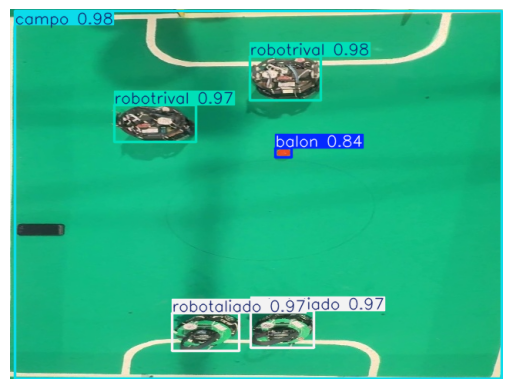

In [ ]:

# 1. modelo entrenado
model = YOLO("runs/runs/detect/train-7/weights/best.pt")

# 2. Ruta de la imagen 
img_path = r"imagenes_homograficas\frame_0001.jpg"

# 3. Ejecucion
results = model.predict(source=img_path, save=True, conf=0.5)

# 4. Mostrar imagen
# YOLO guarda la imagen procesada en runs/detect/predict/
output_img = results[0].plot()  # Devuelve la imagen con bounding boxes
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## Prueba 2 – Integración YOLO + SAM3

En esta prueba se buscó comparar la salida de **YOLO** (detección con bounding boxes) frente a la segmentación de **SAM3** (máscaras a nivel de píxel).  


0: 384x512 1 balon, 1 campo, 2 robotaliados, 2 robotrivals, 13.9ms
Speed: 1272.0ms preprocess, 13.9ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 512)

WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
0: 1036x1036 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 5403.4ms
Speed: 7.7ms preprocess, 5403.4ms inference, 1.4ms postprocess per image at shape (1, 3, 1036, 1036)


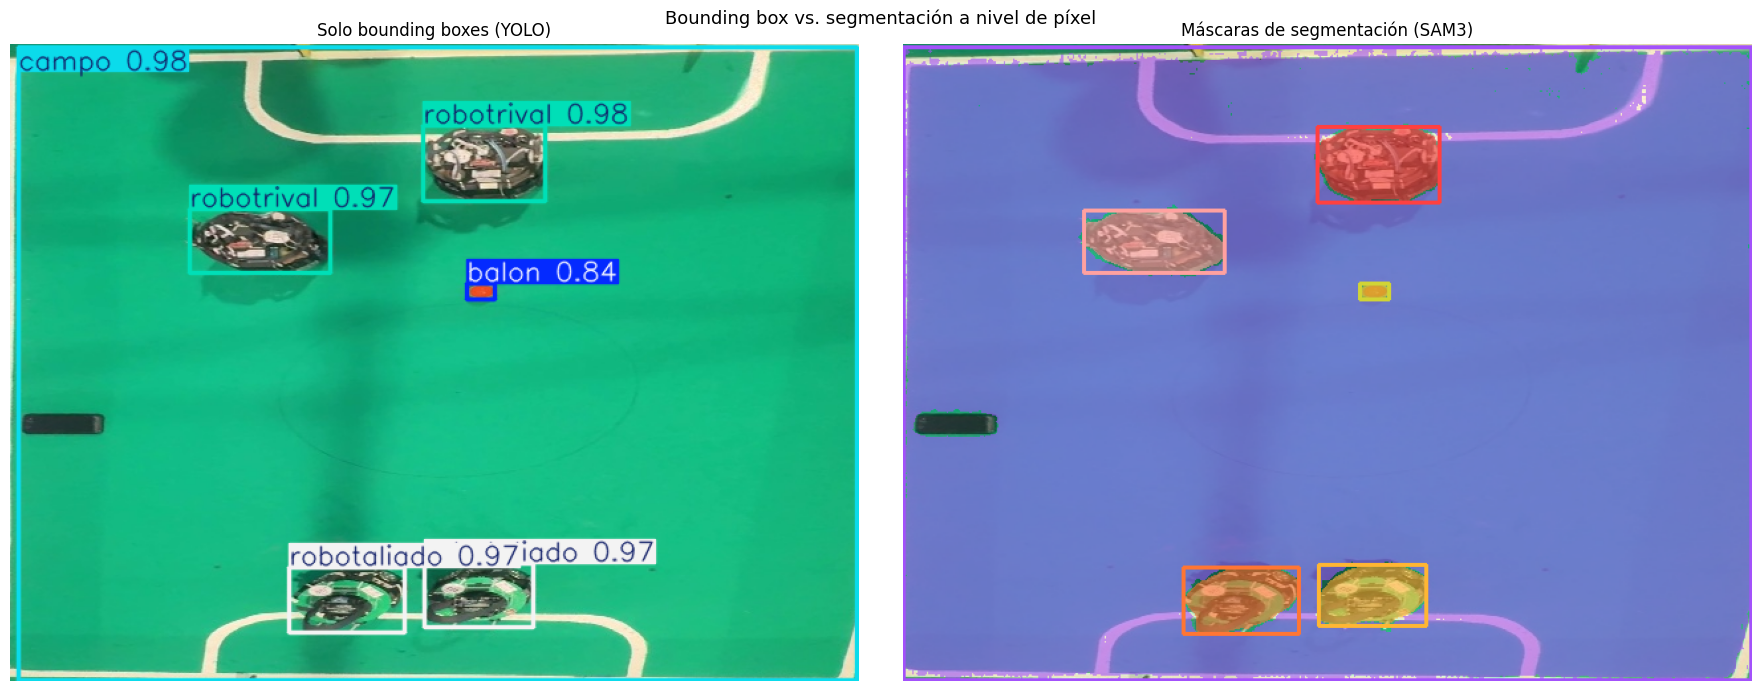

In [ ]:

# 2. Cargar SAM3 
sam_model = SAM("sam3.pt")  

# 3. Ruta de la imagen
img_path = r"imagenes_homograficas\frame_0001.jpg"
image = cv2.imread(img_path)

# 4. Deteccion con YOLO
yolo_results = yolo_model(image, conf=0.5)[0]
scene_yolo = yolo_results.plot()  # imagen con bounding boxes

# 5. Extraer bounding boxes y pasarlas a SAM3
bboxes = yolo_results.boxes.xyxy.tolist()
sam_results = sam_model(image, bboxes=bboxes)[0]

# 6. Convertir resultados SAM a formato Supervision
sam_detections = sv.Detections.from_ultralytics(sam_results)

# 7. Anotar máscaras y cajas
mask_annotator = sv.MaskAnnotator(opacity=0.6)
box_annotator = sv.BoxAnnotator()

annotated_sam = mask_annotator.annotate(scene=image.copy(), detections=sam_detections)
annotated_sam = box_annotator.annotate(scene=annotated_sam, detections=sam_detections)

# 8. comparacion YOLO vs SAM3
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
ax1.imshow(cv2.cvtColor(scene_yolo, cv2.COLOR_BGR2RGB))
ax1.set_title("Solo bounding boxes (YOLO)")
ax1.axis("off")
ax2.imshow(cv2.cvtColor(annotated_sam, cv2.COLOR_BGR2RGB))
ax2.set_title("Máscaras de segmentación (SAM3)")
ax2.axis("off")
plt.suptitle("Bounding box vs. segmentación a nivel de píxel", fontsize=13)
plt.tight_layout()
plt.show()


## Prueba 3 – YOLO + SAM3 + ByteTrack

En esta prueba se integraron los tres componentes principales del pipeline:  
- **YOLO** para detección de objetos.  
- **SAM3** para segmentación a nivel de píxel, usando las cajas de YOLO como prompts visuales.  
- **ByteTrack** para asignar IDs persistentes y rastrear cada objeto en la escena.  


0: 384x512 1 balon, 1 campo, 2 robotaliados, 2 robotrivals, 13.0ms
Speed: 494.2ms preprocess, 13.0ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 512)

WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
0: 1036x1036 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 3758.5ms
Speed: 7.8ms preprocess, 3758.5ms inference, 1.3ms postprocess per image at shape (1, 3, 1036, 1036)


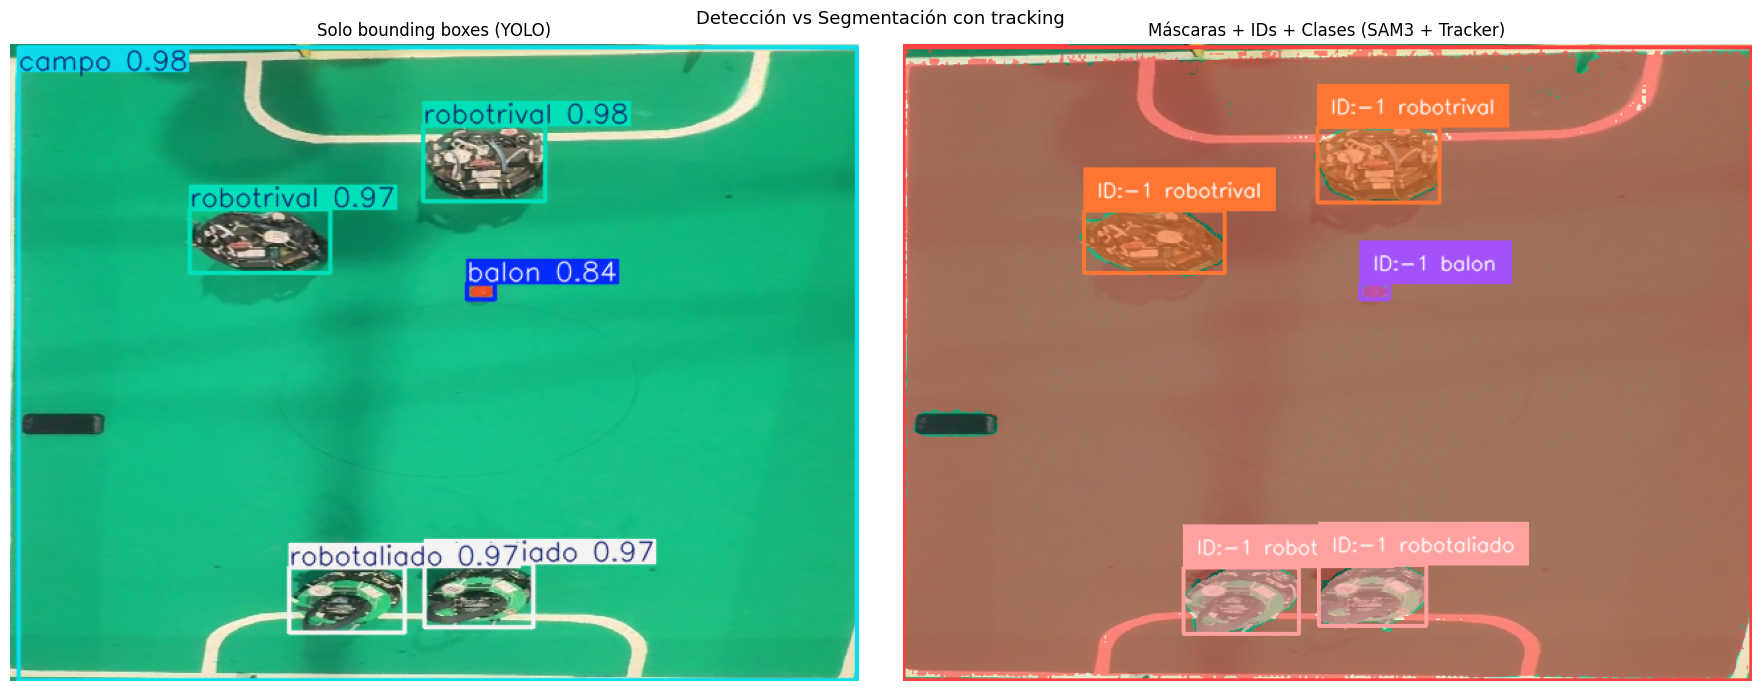

In [ ]:

# 2. Leer imagen
img_path = r"imagenes_homograficas/frame_0001.jpg"
image = cv2.imread(img_path)
if image is None:
    raise FileNotFoundError(f"No se encontro la imagen en {img_path}")

# 3. YOLO
yolo_results = yolo_model(image, conf=0.5)[0]
scene_yolo = yolo_results.plot()

# 4. Segmentacion SAM con cajas YOLO
bboxes = yolo_results.boxes.xyxy.tolist()
sam_results = sam_model(image, bboxes=bboxes)[0]
sam_detections = sv.Detections.from_ultralytics(sam_results)

# 5. Transferir clases y confianza de YOLO a SAM
if len(sam_detections) == len(yolo_results.boxes):
    sam_detections.class_id   = yolo_results.boxes.cls.cpu().numpy().astype(int)
    sam_detections.confidence = yolo_results.boxes.conf.cpu().numpy()

# 6. Tracking
tracker = ByteTrackTracker()
sam_detections = tracker.update(sam_detections)

# 7. Anotación con clases + IDs
mask_annotator  = sv.MaskAnnotator(opacity=0.6)
box_annotator   = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

labels = [
    f"ID:{tid} {yolo_results.names[cid]}"
    for tid, cid in zip(sam_detections.tracker_id, sam_detections.class_id)
]

annotated_sam = mask_annotator.annotate(scene=image.copy(), detections=sam_detections)
annotated_sam = box_annotator.annotate(scene=annotated_sam, detections=sam_detections)
annotated_sam = label_annotator.annotate(scene=annotated_sam, detections=sam_detections, labels=labels)

# 8. Mostrar comparación YOLO vs SAM3 + Tracker
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
ax1.imshow(cv2.cvtColor(scene_yolo, cv2.COLOR_BGR2RGB))
ax1.set_title("Solo bounding boxes (YOLO)")
ax1.axis("off")
ax2.imshow(cv2.cvtColor(annotated_sam, cv2.COLOR_BGR2RGB))
ax2.set_title("Máscaras + IDs + Clases (SAM3 + Tracker)")
ax2.axis("off")
plt.suptitle("Detección vs Segmentación con tracking", fontsize=13)
plt.tight_layout()
plt.show()


### Nota sobre IDs en imágenes estáticas
En esta prueba todos los objetos aparecen con **ID:1**.  
Esto ocurre porque el tracker (ByteTrack) requiere **múltiples frames consecutivos** para asignar y mantener IDs diferentes a cada objeto.  
En una sola imagen no existe continuidad temporal, por lo que el tracker asigna únicamente un ID inicial.  
Para ver IDs distintos y persistentes es necesario ejecutar el pipeline sobre un **video completo o una secuencia de imágenes**.


## Prueba 4 – Video Fase 1 (YOLO + ByteTrack)

En esta fase se aplicó el pipeline sobre el video original del partido (`OriginalFutbot.mp4`), integrando detección con YOLO y tracking con ByteTrack.  
El objetivo fue generar un video anotado con colores por clase y un archivo CSV con las detecciones y tracks.

### Flujo:
- **YOLO** detecta los objetos en cada frame (balón, campo, robots aliados y rivales).  
- **ByteTrack** asigna IDs persistentes a cada objeto, con parámetros ajustados para mayor estabilidad en robots.  
- **Colores por clase**:  
  - Balón → naranja  
  - Robot aliado → azul  
  - Robot rival → amarillo  
  - Campo → verde  
- **CSV**: se guardan las detecciones con frame, ID, clase, coordenadas y confianza.  
- **Video salida**: `fase1_yolo_bytetrack.mp4` con bounding boxes coloreados e IDs. 

In [ ]:

print("Fase 1: YOLO + ByteTrack con mejoras")

# Cargar YOLO
yolo = YOLO("runs/runs/detect/train-7/weights/best.pt")

# Abrir video
cap = cv2.VideoCapture("videos/OriginalFutbot.mp4")
fps = int(cap.get(cv2.CAP_PROP_FPS))
w, h = int(cap.get(3)), int(cap.get(4))

tracker = ByteTrackTracker(
    lost_track_buffer=90,            # más tolerancia, útil para balón
    frame_rate=fps,
    track_activation_threshold=0.35, # activa mas rapido el balon
    minimum_consecutive_frames=2,    # exige consistencia en 2 frames
    minimum_iou_threshold=0.5,       # menos estricto en emparejar
    high_conf_det_threshold=0.8      # solo confirma con alta confianza
)


out = cv2.VideoWriter("fase1_yolo_bytetrack.mp4", cv2.VideoWriter_fourcc(*'mp4v'), fps, (w,h))

# IDs fijos
BALL_CLASS_ID = 0   
BALL_FIXED_ID = 1

# Colores por clase (BGR)
COLORS = {
    BALL_CLASS_ID: (0, 140, 255),   # balon naranja
    2: (255, 0, 0),                 # robot aliado azul
    3: (0, 255, 255),               # robot rival amarillo
    1: (0, 255, 0)                  # campo verde
}

# CSV con detecciones y tracks
csv_file = open("detecciones_yolo.csv","w",newline="")
writer = csv.writer(csv_file)
writer.writerow(["frame","id","class","x1","y1","x2","y2","conf","cx","cy","area"])

# Historial de trazas
traces = defaultdict(list)

frame_id = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break
    frame_id += 1
    print(f"\nFrame {frame_id}")

    # YOLO con no_grad para acelerar
    with torch.no_grad():
        results = yolo.predict(frame, conf=0.5, imgsz=960)[0]
    detections = sv.Detections.from_ultralytics(results)
    print(f"YOLO detecto {len(detections)} objetos")

    # ByteTrack tracking
    tracks = tracker.update(detections)
    print(f"ByteTrack devolvió {len(tracks)} tracks")

    # Conteo por clase
    class_counts = {}
    for cid in detections.class_id:
        class_counts[cid] = class_counts.get(cid,0)+1
    print("Conteo por clase:", class_counts)

    # Dibujar bounding boxes con grosor proporcional a confianza
    for box, conf, cid in zip(detections.xyxy, detections.confidence, detections.class_id):
        x1, y1, x2, y2 = map(int, box)
        class_name = yolo.names[int(cid)]
        color = COLORS.get(int(cid), (0,255,0))
        thickness = int(1 + conf*3)
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, thickness)
        cv2.putText(frame, f"{class_name} {conf:.2f}", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    # Dibujar IDs y trazas
    for box, tid, cid in zip(tracks.xyxy, tracks.tracker_id, tracks.class_id):
        if tid == -1: continue
        x1, y1, x2, y2 = map(int, box)

        if cid == BALL_CLASS_ID:
            tid = BALL_FIXED_ID

        color = COLORS.get(int(cid), (255,0,0))
        cv2.putText(frame, f"ID {tid}", (x1, y2+20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        # Guardar trazas (últimos 15 puntos)
        cx, cy = int((x1+x2)/2), int((y1+y2)/2)
        traces[tid].append((cx,cy))
        if len(traces[tid]) > 15:
            traces[tid].pop(0)
        for i in range(1,len(traces[tid])):
            cv2.line(frame, traces[tid][i-1], traces[tid][i], color, 2)

    # Guardar en CSV
    for box, tid, cid, conf in zip(tracks.xyxy, tracks.tracker_id, tracks.class_id, tracks.confidence):
        if tid == -1: continue
        x1,y1,x2,y2 = box
        if cid == BALL_CLASS_ID:
            tid = BALL_FIXED_ID
        cx, cy = (x1+x2)/2, (y1+y2)/2
        area = (x2-x1)*(y2-y1)
        writer.writerow([frame_id,tid,int(cid),x1,y1,x2,y2,float(conf),cx,cy,area])

    out.write(frame)

cap.release()
out.release()
csv_file.close()
print("Fase 1 completada: video con mejoras y CSV enriquecido")


## Prueba 5 – Fase 2 (YOLO + ByteTrack + SAM3 con CSV)

En esta fase se integró **SAM3** al pipeline, utilizando las detecciones de YOLO (almacenadas en `detecciones_yolo.csv`) como *prompts visuales*.  
El objetivo fue obtener segmentaciones a nivel de píxel, transferir clases e IDs, y generar un video anotado con máscaras, etiquetas y trazas.

### Flujo:
- Se cargó el CSV con las detecciones de YOLO + ByteTrack.  
- Se separaron los objetos móviles (robots y balón) del campo.  
- Se aplicó **SAM3** usando las cajas de YOLO como entrada.  
- Se transfirieron las clases y la confianza de YOLO a las máscaras de SAM3.  
- Se fijó el **ID de la pelota = 1** para mantener consistencia en todo el video.  
- Se añadieron anotaciones con máscaras, etiquetas y trazas de movimiento.  
- Se generó el video final: `videos/Futbot_sam_csvYolo.mp4`.

In [ ]:
print("Fase 2: SAM con cajas de YOLO como prompts + visualización optimizada")

# Inicializar SAM
sam_model = SAM("sam3.pt")

# IDs de clases
CAMPO_CLASS_ID       = 1
PELOTA_CLASS_ID      = 0
ROBOT_ALIADO_CLASSID = 2
ROBOT_RIVAL_CLASSID  = 3

# Diccionario de nombres
class_names = {
    CAMPO_CLASS_ID: "Campo",
    PELOTA_CLASS_ID: "Pelota",
    ROBOT_ALIADO_CLASSID: "Aliado",
    ROBOT_RIVAL_CLASSID: "Rival"
}

# Colores por clase
palette = sv.ColorPalette([
    sv.Color(0,255,0),      # Campo verde
    sv.Color(0,140,255),    # Pelota naranja
    sv.Color(0,0,255),      # Aliados azules
    sv.Color(255,255,0)     # Rivales amarillos
])

# Anotadores con escala más pequeña
mask_annotator  = sv.MaskAnnotator(opacity=0.5, color_lookup=sv.ColorLookup.CLASS, color=palette)
label_annotator = sv.LabelAnnotator(text_scale=0.4, text_thickness=1, text_padding=2, color=sv.Color.BLACK)
trace_annotator = sv.TraceAnnotator()  # sin argumentos, compatible

# Tracker con parámetros ajustados
tracker = ByteTrackTracker(
    lost_track_buffer=90,
    track_activation_threshold=0.35,
    minimum_consecutive_frames=2,
    minimum_iou_threshold=0.5,
    high_conf_det_threshold=0.8
)

# Cargar CSV
df = pd.read_csv("detecciones_yolo.csv")

def procesar_frame_sam(frame: np.ndarray, frame_id: int) -> np.ndarray:
    rows = df[df["frame"] == frame_id]
    if len(rows) == 0:
        return frame

    # Objetos móviles
    rows_otros = rows[rows["class"] != CAMPO_CLASS_ID]
    yolo_det = sv.Detections(
        xyxy=rows_otros[["x1","y1","x2","y2"]].values,
        confidence=rows_otros["conf"].values,
        class_id=rows_otros["class"].values,
        tracker_id=rows_otros["id"].values
    )
    yolo_det = tracker.update(yolo_det)

    # Campo
    rows_campo = rows[rows["class"] == CAMPO_CLASS_ID]
    campo_det = sv.Detections(
        xyxy=rows_campo[["x1","y1","x2","y2"]].values,
        confidence=rows_campo["conf"].values,
        class_id=rows_campo["class"].values,
        tracker_id=np.array([None]*len(rows_campo))
    )

    # Concatenar detecciones
    if len(campo_det) > 0:
        all_dets = sv.Detections(
            xyxy=np.vstack([yolo_det.xyxy, campo_det.xyxy]),
            confidence=np.concatenate([yolo_det.confidence, campo_det.confidence]),
            class_id=np.concatenate([yolo_det.class_id, campo_det.class_id]),
            tracker_id=np.concatenate([yolo_det.tracker_id, campo_det.tracker_id])
        )
    else:
        all_dets = yolo_det

    if len(all_dets) == 0:
        return frame

    # SAM con cajas de YOLO
    sam_results = sam_model.predict(frame, bboxes=all_dets.xyxy.tolist(), imgsz=640, verbose=False)[0]
    sam_det = sv.Detections.from_ultralytics(sam_results)

    if sam_det is not None and len(sam_det) == len(all_dets):
        sam_det.tracker_id = all_dets.tracker_id
        sam_det.class_id   = all_dets.class_id
        sam_det.confidence = all_dets.confidence

        # Pelota siempre con ID fijo = 1
        if sam_det.tracker_id is not None:
            sam_det.tracker_id[sam_det.class_id == PELOTA_CLASS_ID] = 1

    # Etiquetas
    labels = []
    if sam_det is not None and sam_det.tracker_id is not None and sam_det.class_id is not None:
        for tid, cid in zip(sam_det.tracker_id, sam_det.class_id):
            nombre = class_names.get(cid, f"Clase {cid}")
            labels.append(nombre if cid == CAMPO_CLASS_ID else f"{nombre} ID:{tid}")

    # Anotaciones
    annotated = mask_annotator.annotate(scene=frame.copy(), detections=sam_det)
    if labels:
        annotated = label_annotator.annotate(scene=annotated, detections=sam_det, labels=labels)

    # Trazas (solo objetos móviles)
    if sam_det is not None and sam_det.tracker_id is not None:
        moviles = sam_det[sam_det.class_id != CAMPO_CLASS_ID]
        if len(moviles) > 0:
            annotated = trace_annotator.annotate(scene=annotated, detections=moviles)

    # Mostrar en vivo cada 10 frames para no saturar
    if frame_id % 10 == 0:
        cv2.imshow("Segmentación Futbot", annotated)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            cv2.destroyAllWindows()
            exit()

    return annotated

# Procesar video
sv.process_video(
    source_path="videos/OriginalFutbot.mp4",
    target_path="videos/Futbot_sam_csvYolo.mp4",
    callback=procesar_frame_sam
)

print("Guardado: videos/Futbot_sam_csvYolo.mp4")


## Fase 3 – Análisis de posesión y mapas de calor

En esta fase se aprovechan las detecciones y tracks generados en Fase 1 y Fase 2 para calcular métricas de juego y visualizaciones tácticas.

### Flujo:
- **Normalización de coordenadas**: todas las detecciones se escalan al tamaño real de la cancha (243 × 182 cm).  
- **Cálculo de posesión**: se determina qué equipo está más cerca del balón en cada frame, asignando posesión a aliados o rivales.  
- **Visualizaciones**:
  - **Trayectoria del balón** sobre la cancha, mostrando su recorrido y última posición.  
  - **Mapa de calor sobre la cancha** para aliados y rivales, indicando las zonas de mayor actividad.  

Posesión Aliados: 39.18%
Posesión Rivales: 57.41%


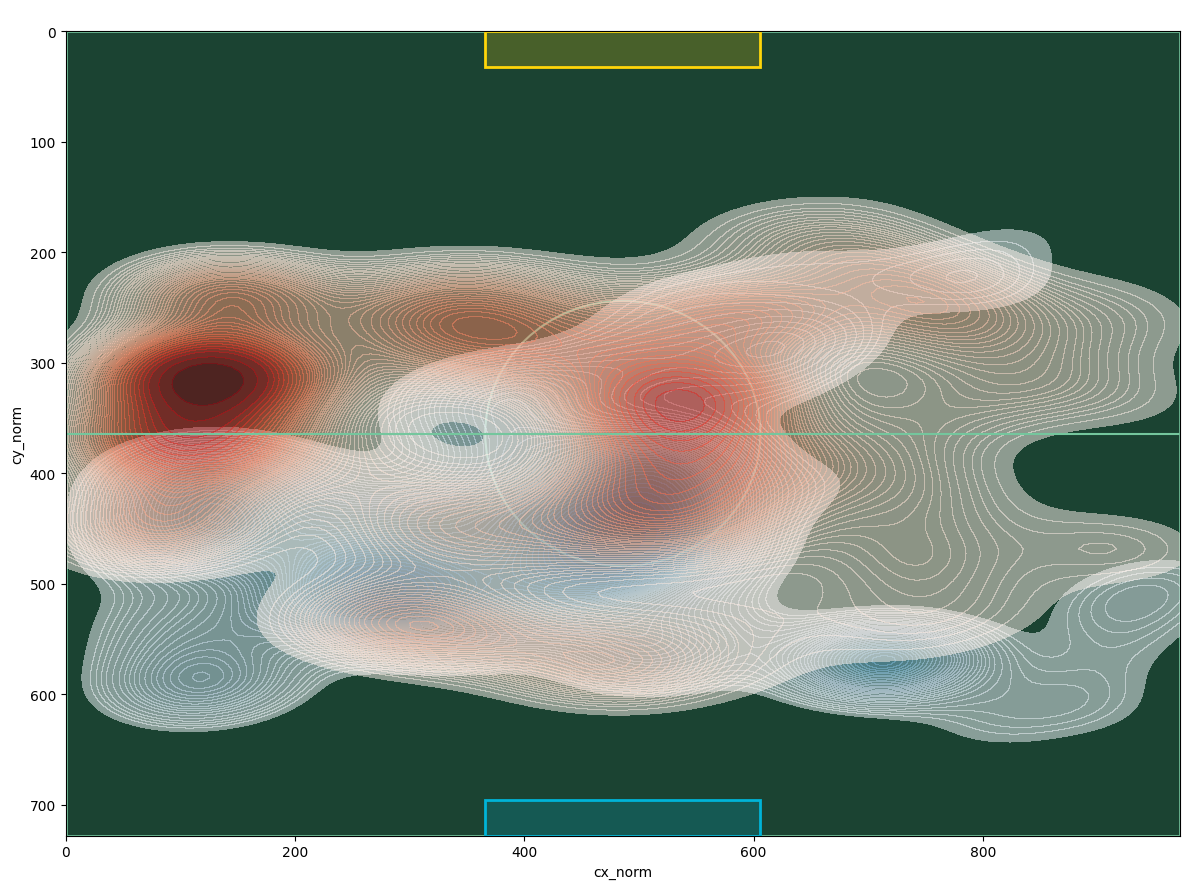

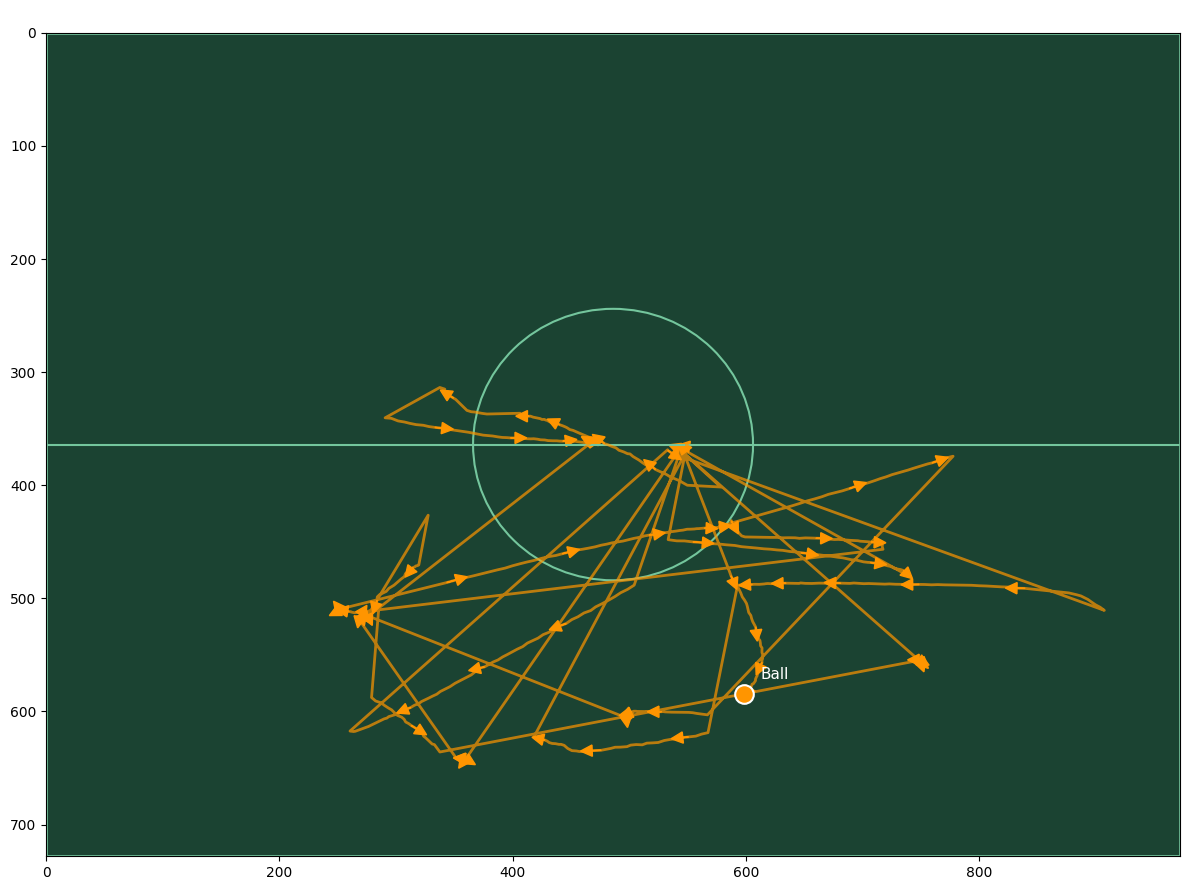

In [ ]:
# --- Dimensiones reales de la cancha ---
CAMPO_W_CM, CAMPO_H_CM = 243, 182
ESCALA_PX_CM = 4
CAMPO_W, CAMPO_H = CAMPO_W_CM * ESCALA_PX_CM, CAMPO_H_CM * ESCALA_PX_CM

# --- Leer CSV con detecciones ---
df = pd.read_csv("detecciones_yolo.csv")

# Calcular centro de cada objeto
df["cx"] = (df["x1"] + df["x2"]) / 2
df["cy"] = (df["y1"] + df["y2"]) / 2

# Normalizar coordenadas al rango de la cancha
max_x, max_y = df["cx"].max(), df["cy"].max()
df["cx_norm"] = df["cx"] / max_x * CAMPO_W
df["cy_norm"] = df["cy"] / max_y * CAMPO_H

# Separar clases normalizadas
ball    = df[df["class"] == 0]
aliados = df[df["class"] == 2]
rivales = df[df["class"] == 3]

# --- Cálculo de posesión ---
def nearest_robot(frame):
    ball_f = ball[ball["frame"] == frame]
    robots = df[(df["frame"] == frame) & (df["class"].isin([2,3]))].copy()
    if ball_f.empty or robots.empty: return None
    bx, by = ball_f.iloc[0][["cx_norm","cy_norm"]]
    robots["dist"] = np.sqrt((robots["cx_norm"]-bx)**2 + (robots["cy_norm"]-by)**2)
    return robots.loc[robots["dist"].idxmin()]["class"]

posesion = [nearest_robot(f) for f in ball["frame"].unique()]
aliados_pos = posesion.count(2)/len(posesion)
rivales_pos = posesion.count(3)/len(posesion)

print(f"Posesión Aliados: {aliados_pos:.2%}")
print(f"Posesión Rivales: {rivales_pos:.2%}")

# Exportar métricas de posesión por frame
pd.DataFrame({"frame": ball["frame"].unique(), "posesion": posesion}).to_csv("posesion_por_frame.csv", index=False)

# --- Función para dibujar cancha con heatmap ---
def draw_field_with_heatmap(aliados, rivales, campo_w=CAMPO_W, campo_h=CAMPO_H):
    fig, ax = plt.subplots(figsize=(12,9))
    ax.set_facecolor("#1b4332")
    ax.set_xlim(0, campo_w)
    ax.set_ylim(campo_h, 0)

    # Campo y porterías
    ax.add_patch(mpatches.Rectangle((0,0), campo_w, campo_h,
                 lw=2, edgecolor="#74c69d", facecolor="none"))
    ax.axhline(y=campo_h/2, color="#74c69d", lw=1.5)
    ax.add_patch(plt.Circle((campo_w/2, campo_h/2), radius=30*ESCALA_PX_CM,
                 color="#74c69d", fill=False, lw=1.5))

    goal_w = 60*ESCALA_PX_CM
    goal_x = (campo_w - goal_w)/2
    ax.add_patch(mpatches.Rectangle((goal_x,0), goal_w, 8*ESCALA_PX_CM,
                 lw=2, edgecolor="#ffd60a", facecolor="#ffd60a33"))
    ax.add_patch(mpatches.Rectangle((goal_x,campo_h-8*ESCALA_PX_CM), goal_w, 8*ESCALA_PX_CM,
                 lw=2, edgecolor="#00b4d8", facecolor="#00b4d833"))

    # Heatmap de aliados y rivales
    sns.kdeplot(x=aliados["cx_norm"], y=aliados["cy_norm"], cmap="Blues", fill=True, alpha=0.5, ax=ax, levels=50)
    sns.kdeplot(x=rivales["cx_norm"], y=rivales["cy_norm"], cmap="Reds", fill=True, alpha=0.5, ax=ax, levels=50)

    ax.set_title("Mapa de calor sobre cancha (Aliados vs Rivales)", fontsize=13, color="white")
    plt.tight_layout()
    plt.show()

# Dibujar mapa de calor
draw_field_with_heatmap(aliados, rivales)

# --- Trayectoria del balón ---
ball_positions = list(zip(ball["cx_norm"], ball["cy_norm"]))

def draw_ball_trajectory(ball_positions, campo_w=CAMPO_W, campo_h=CAMPO_H):
    fig, ax = plt.subplots(figsize=(12,9))
    ax.set_facecolor("#1b4332")
    ax.set_xlim(0, campo_w)
    ax.set_ylim(campo_h, 0)

    # Campo
    ax.add_patch(mpatches.Rectangle((0,0), campo_w, campo_h,
                 lw=2, edgecolor="#74c69d", facecolor="none"))
    ax.axhline(y=campo_h/2, color="#74c69d", lw=1.5)
    ax.add_patch(plt.Circle((campo_w/2, campo_h/2), radius=30*ESCALA_PX_CM,
                 color="#74c69d", fill=False, lw=1.5))

    # Trayectoria con flechas
    xs, ys = zip(*ball_positions)
    ax.plot(xs, ys, color="#ff9500", linewidth=2, alpha=0.7, zorder=4)
    for i in range(1, len(xs), 15):  # flecha cada 15 frames
        dx, dy = xs[i]-xs[i-1], ys[i]-ys[i-1]
        ax.arrow(xs[i-1], ys[i-1], dx, dy, head_width=10, head_length=10, fc="#ff9500", ec="#ff9500")

    ax.scatter(xs[-1], ys[-1], s=180, c="#ff9500", zorder=6,
               edgecolors="white", linewidths=1.5, marker="o")
    ax.text(xs[-1]+14, ys[-1]-14, "Ball", fontsize=11, color="white", zorder=6)

    ax.set_title("Trayectoria del balón sobre cancha", fontsize=13, color="white")
    plt.tight_layout()
    plt.show()

# Dibujar trayectoria del balón
draw_ball_trajectory(ball_positions)


In [36]:
import pandas as pd
import numpy as np
import cv2

# --- Leer CSV con detecciones ---
df = pd.read_csv("detecciones_yolo.csv")
df["cx"] = (df["x1"] + df["x2"]) / 2
df["cy"] = (df["y1"] + df["y2"]) / 2
ball = df[df["class"] == 0]

# --- Coordenadas de las porterías ---
goal_sup = [(217,97),(391,97)]
goal_inf = [(140,732),(305,767)]

# --- Función distancia punto-línea ---
def dist_point_line(px, py, p1, p2):
    x1,y1 = p1
    x2,y2 = p2
    num = abs((y2-y1)*px - (x2-x1)*py + x2*y1 - y2*x1)
    den = np.sqrt((y2-y1)**2 + (x2-x1)**2)
    return num/den

# --- Posiciones de balón por frame ---
ball_positions = {int(row["frame"]):(row["cx"],row["cy"]) for _,row in ball.iterrows()}

# --- Parámetros detección ---
umbral = 12
min_gap = 30
ultimo_gol_frame = None
goles_detectados = []

# --- Cargar video original ---
cap = cv2.VideoCapture("videos/OriginalFutbot.mp4")
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# --- Configurar salida ---
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter("video_goles.mp4", fourcc, fps, (w,h))

while True:
    ret, frame = cap.read()
    if not ret: break
    frame_id = int(cap.get(cv2.CAP_PROP_POS_FRAMES))

    # Dibujar líneas de gol
    cv2.line(frame, goal_sup[0], goal_sup[1], (0,0,255), 2)
    cv2.line(frame, goal_inf[0], goal_inf[1], (0,0,255), 2)

    # Si hay pelota en este frame
    if frame_id in ball_positions:
        cx, cy = ball_positions[frame_id]
        cv2.circle(frame, (int(cx),int(cy)), 8, (0,255,0), -1)

        d_sup = dist_point_line(cx, cy, goal_sup[0], goal_sup[1])
        d_inf = dist_point_line(cx, cy, goal_inf[0], goal_inf[1])

        if d_sup <= umbral and (ultimo_gol_frame is None or frame_id-ultimo_gol_frame>min_gap):
            cv2.putText(frame, "⚽ GOL SUPERIOR!", (50,50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,255), 2)
            ultimo_gol_frame = frame_id
            goles_detectados.append((frame_id,"Gol en portería superior"))
            print(f"Frame {frame_id}: Gol en portería superior")

        if d_inf <= umbral and (ultimo_gol_frame is None or frame_id-ultimo_gol_frame>min_gap):
            cv2.putText(frame, "⚽ GOL INFERIOR!", (50,100), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,255), 2)
            ultimo_gol_frame = frame_id
            goles_detectados.append((frame_id,"Gol en portería inferior"))
            print(f"Frame {frame_id}: Gol en portería inferior")

    out.write(frame)

cap.release()
out.release()

# --- Exportar resumen ---
pd.DataFrame(goles_detectados, columns=["frame","evento"]).to_csv("goles_detectados.csv", index=False)

print("\n✅ Video generado: video_goles.mp4")
print("✅ CSV exportado: goles_detectados.csv")


Frame 998: Gol en portería inferior
Frame 1029: Gol en portería inferior
Frame 1060: Gol en portería inferior
Frame 1652: Gol en portería inferior

✅ Video generado: video_goles.mp4
✅ CSV exportado: goles_detectados.csv


In [38]:
import cv2
import numpy as np

# Abrir los cuatro videos
cap_orig = cv2.VideoCapture("videos/OriginalFutbot.mp4")
cap_yolo = cv2.VideoCapture("fase1_yolo_bytetrack.mp4")
cap_sam3 = cv2.VideoCapture("videos/Futbot_sam_csvYolo.mp4")
cap_goles = cv2.VideoCapture("video_goles.mp4")

fps = int(cap_orig.get(cv2.CAP_PROP_FPS))
w = int(cap_orig.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap_orig.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Configurar salida en cuadrícula 2x2
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter("fase3_final.mp4", fourcc, fps, (w*2, h*2))

while True:
    ret0, f0 = cap_orig.read()
    ret1, f1 = cap_yolo.read()
    ret2, f2 = cap_sam3.read()
    ret3, f3 = cap_goles.read()
    if not (ret0 and ret1 and ret2 and ret3):
        break

    # Redimensionar todos al mismo tamaño
    f0 = cv2.resize(f0, (w,h))
    f1 = cv2.resize(f1, (w,h))
    f2 = cv2.resize(f2, (w,h))
    f3 = cv2.resize(f3, (w,h))

    # Concatenar en cuadrícula 2x2
    top = np.hstack((f0, f1))
    bottom = np.hstack((f2, f3))
    grid = np.vstack((top, bottom))

    # Añadir títulos
    cv2.putText(grid, "Original", (50,50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
    cv2.putText(grid, "YOLO + ByteTrack", (w+50,50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
    cv2.putText(grid, "SAM3 Segmentacion", (50,h+50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
    cv2.putText(grid, "Deteccion de Goles", (w+50,h+50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)

    out.write(grid)

cap_orig.release()
cap_yolo.release()
cap_sam3.release()
cap_goles.release()
out.release()

print("✅ Video final demo generado: fase3_final.mp4")


✅ Video final demo generado: fase3_final.mp4


Breve explicacion- El enfoque utilizado combina detección de objetos con YOLO y seguimiento con ByteTrack para obtener las trayectorias de robots y balón. Posteriormente, se emplea SAM3 como modelo de segmentación para separar campo, aliados y rivales con mayor precisión. Con estas salidas se generan métricas de posesión, mapas de calor y trayectorias del balón. Finalmente, se implementa un módulo de detección automática de goles que analiza la posición de la pelota respecto a las porterías. Este pipeline permite narrar el partido de forma automática, integrando visión por computadora y análisis estadístico